# Visualisation — Résidu EGT moyen par vol
**Objectif** : détecter une dérive progressive du moteur en suivant le résidu EGT (réel − prédit) dans l'ordre chronologique.

Cellules :
1. Imports & utilitaires
2. Pipeline complet (RF → résidus → LightGBM) — **à exécuter une seule fois**
3. Calcul des résidus EGT par vol
4. Visualisation

## 1 — Imports & utilitaires

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Chemins ---
project_root = Path().resolve()
sys.path.insert(0, str(project_root / "external"))

from tabata import Opset
from config import (
    AIRCRAFT_FILES, N_TRAIN_VOLS,
    VAR_CONTEXTE, VAR_MOTEUR, TARGET,
    VAR_CONTEXTE_FINAL, VAR_MOTEUR_FINAL
)
from RF_model import select_train_vols, train_rf, compute_residuals, train_final_model
import RF_model as _rf
import config as _cfg

_rf.TARGET = TARGET  # TARGET non importé dans RF_model — patch


def clean_col_names(df):
    """Remplace les caractères spéciaux JSON (requis par LightGBM) par des underscores."""
    df = df.copy()
    df.columns = (
        df.columns
        .str.replace(r'[\[\]{}",:\ ]', '_', regex=True)
        .str.replace('%', 'pct', regex=False)
        .str.replace(r'_+', '_', regex=True)
        .str.rstrip('_')
    )
    return df


def clean_list(lst):
    """Retourne les noms nettoyés d'une liste de colonnes."""
    return list(clean_col_names(pd.DataFrame(columns=lst)).columns)


def reset_config():
    """Réinitialise les constantes patchées entre deux avions."""
    for mod in (_cfg, _rf):
        mod.VAR_CONTEXTE       = VAR_CONTEXTE
        mod.VAR_MOTEUR         = VAR_MOTEUR
        mod.VAR_CONTEXTE_FINAL = VAR_CONTEXTE_FINAL
        mod.VAR_MOTEUR_FINAL   = VAR_MOTEUR_FINAL
        mod.TARGET             = TARGET


print("Imports OK")

Imports OK


## 2 — Pipeline complet  
> ⚠️ **Exécuter une seule fois** — calcul lourd (RF + LightGBM × 3 avions)

In [3]:
pipelines = {}  # stocke les résultats bruts pour chaque avion

for idx, aircraft_file in enumerate(AIRCRAFT_FILES, start=1):
    nom = f"Avion {idx}"
    print(f"\n{'='*50}")
    print(f"{nom} — {aircraft_file.name}")
    print(f"{'='*50}")

    reset_config()

    # Chargement
    opset  = Opset(str(aircraft_file))
    n_vols = len(opset)
    print(f"Vols disponibles : {n_vols}")

    # RF
    print("Entraînement RF...")
    X_train, Y_train = select_train_vols(opset, n_train=N_TRAIN_VOLS)
    rf_model         = train_rf(X_train, Y_train)
    print(f"  R² in-sample RF : {rf_model.score(X_train, Y_train):.4f}")

    # Résidus
    print("Calcul des résidus...")
    residuals, residuals_norm, norm_params, contexts = compute_residuals(rf_model, opset)

    # Nettoyage noms colonnes
    VAR_CTX_C   = clean_list(VAR_CONTEXTE)
    VAR_MOT_C   = clean_list(VAR_MOTEUR)
    VAR_CTX_F_C = clean_list(VAR_CONTEXTE_FINAL)
    VAR_MOT_F_C = clean_list(VAR_MOTEUR_FINAL)
    TARGET_C    = clean_list([TARGET])[0]

    residuals_norm = clean_col_names(residuals_norm)
    contexts       = clean_col_names(contexts)

    for mod in (_cfg, _rf):
        mod.VAR_CONTEXTE       = VAR_CTX_C
        mod.VAR_MOTEUR         = VAR_MOT_C
        mod.VAR_CONTEXTE_FINAL = VAR_CTX_F_C
        mod.VAR_MOTEUR_FINAL   = VAR_MOT_F_C
        mod.TARGET             = TARGET_C

    # LightGBM
    print("Entraînement LightGBM...")
    lgbm_model = train_final_model(residuals_norm, contexts)

    # Stockage
    pipelines[nom] = {
        'lgbm_model'    : lgbm_model,
        'residuals_norm': residuals_norm,
        'contexts'      : contexts,
        'n_vols'        : n_vols,
        'VAR_CTX_F_C'   : VAR_CTX_F_C,
        'VAR_MOT_F_C'   : VAR_MOT_F_C,
        'TARGET_C'      : TARGET_C,
    }
    print(f"{nom} — pipeline terminé ✓")

print("\nTous les pipelines sont prêts.")


Avion 1 — aircraft_1_decollage.h5
Vols disponibles : 997
Entraînement RF...
  R² in-sample RF : 0.9728
Calcul des résidus...
Entraînement LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1802
[LightGBM] [Info] Number of data points in the train set: 403194, number of used features: 8
[LightGBM] [Info] Start training from score 729.033908
Avion 1 — pipeline terminé ✓

Avion 2 — aircraft_2_decollage.h5
Vols disponibles : 1001
Entraînement RF...
  R² in-sample RF : 0.9755
Calcul des résidus...
Entraînement LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009596 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1786
[LightGBM] [Info] Number of data points in the train set: 405000, number of used features: 8
[LightGBM] [Info] Start training fr

## 3 — Calcul des résidus EGT par vol

In [4]:
residus_par_avion = {}

for nom, p in pipelines.items():

    contexts        = p['contexts']
    residuals_norm  = p['residuals_norm']
    lgbm_model      = p['lgbm_model']
    VAR_CTX_F_C     = p['VAR_CTX_F_C']
    VAR_MOT_F_C     = p['VAR_MOT_F_C']
    TARGET_C        = p['TARGET_C']

    # Features et cible sur tous les vols
    X_all      = pd.concat([contexts[VAR_CTX_F_C], residuals_norm[VAR_MOT_F_C]], axis=1)
    Y_all      = contexts[TARGET_C]
    id_vol_all = contexts['id_vol']

    egt_pred     = pd.Series(lgbm_model.predict(X_all), index=Y_all.index)
    egt_residual = Y_all - egt_pred  # réel − prédit

    residus_par_vol = (
        pd.DataFrame({'id_vol': id_vol_all, 'residual': egt_residual})
        .groupby('id_vol')['residual']
        .mean()
        .reset_index()
        .rename(columns={'residual': 'mean_residual'})
    )

    residus_par_avion[nom] = residus_par_vol
    print(f"{nom} : {len(residus_par_vol)} vols, "
          f"résidu moyen = {residus_par_vol['mean_residual'].mean():.2f}°C, "
          f"std = {residus_par_vol['mean_residual'].std():.2f}°C")

print("\nRésidus calculés.")

Avion 1 : 997 vols, résidu moyen = -0.11°C, std = 3.19°C
Avion 2 : 1001 vols, résidu moyen = -0.21°C, std = 3.79°C
Avion 3 : 1000 vols, résidu moyen = -0.29°C, std = 9.63°C

Résidus calculés.


## 4 — Visualisation : dérive EGT par avion

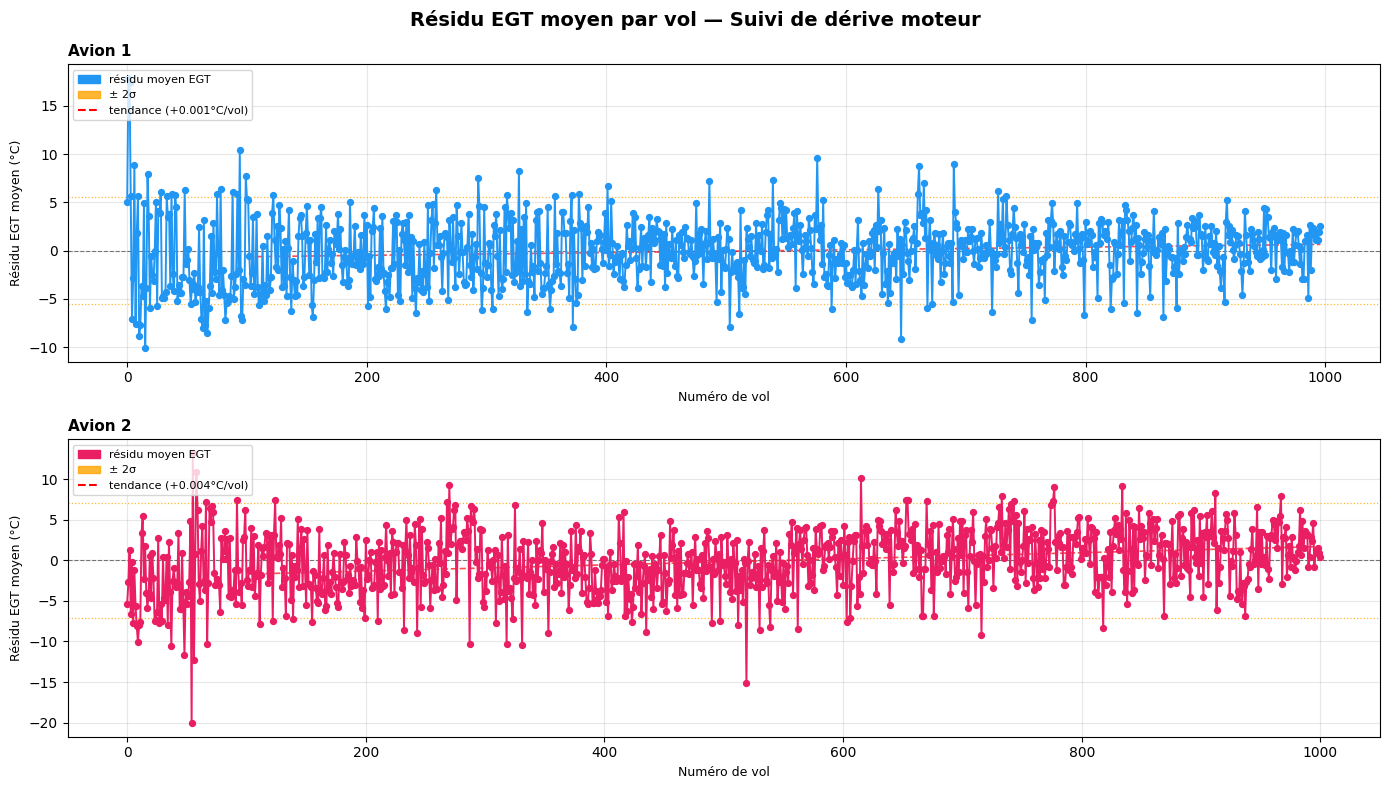

Graphique sauvegardé : visu01_derive_egt.png


In [6]:
COLORS = ['#2196F3', '#E91E63']

avions_a_afficher = ['Avion 1', 'Avion 2']
residus_filtres = {k: v for k, v in residus_par_avion.items() if k in avions_a_afficher}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
fig.suptitle("Résidu EGT moyen par vol — Suivi de dérive moteur",
             fontsize=14, fontweight='bold')

for ax, (nom, residus_par_vol), color in zip(axes, residus_filtres.items(), COLORS):

    ids  = residus_par_vol['id_vol'].values
    vals = residus_par_vol['mean_residual'].values

    mask_out = ids > N_TRAIN_VOLS

    # Tracé uniforme sur tous les vols
    ax.plot(ids, vals, color=color, linewidth=1.4, zorder=3)
    ax.scatter(ids, vals, color=color, s=18, zorder=4)

    # Ligne zéro
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    # Seuils ± 2σ (sur vols out-of-sample uniquement)
    sigma = vals[mask_out].std()
    ax.axhline( 2 * sigma, color='orange', linewidth=0.9, linestyle=':', alpha=0.8)
    ax.axhline(-2 * sigma, color='orange', linewidth=0.9, linestyle=':', alpha=0.8)

    # Tendance linéaire out-of-sample
    if mask_out.sum() > 2:
        z = np.polyfit(ids[mask_out], vals[mask_out], 1)
        p = np.poly1d(z)
        ax.plot(ids[mask_out], p(ids[mask_out]),
                color='red', linewidth=1.2, linestyle='--', alpha=0.7)

    # Légendes
    patch_main  = mpatches.Patch(color=color, label='résidu moyen EGT')
    patch_sigma = mpatches.Patch(color='orange', alpha=0.8, label='± 2σ')
    line_trend  = plt.Line2D([0], [0], color='red', linestyle='--',
                              label=f'tendance ({z[0]:+.3f}°C/vol)')
    ax.legend(handles=[patch_main, patch_sigma, line_trend],
              fontsize=8, loc='upper left')

    ax.set_title(nom, fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel("Résidu EGT moyen (°C)", fontsize=9)
    ax.set_xlabel("Numéro de vol", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("visu01_derive_egt.png", dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : visu01_derive_egt.png")

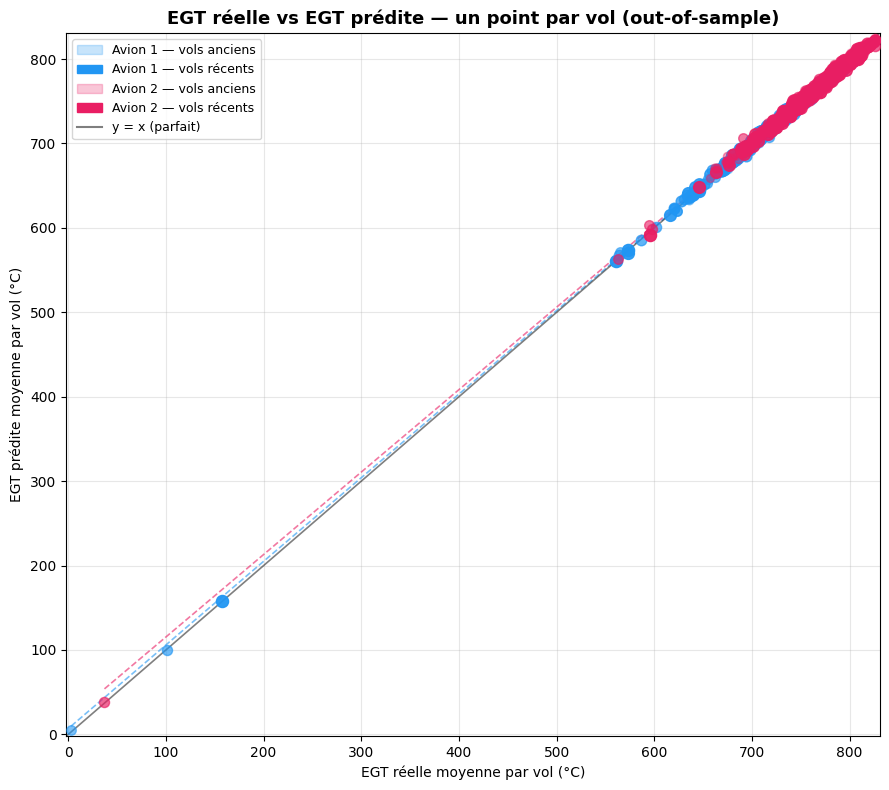

Graphique sauvegardé : visu02_egt_reel_vs_predit.png


In [8]:
# ================================================================
# EGT réelle vs EGT prédite (LightGBM), un point par vol
# ================================================================
COLORS = ['#2196F3', '#E91E63']
avions_a_afficher = ['Avion 1', 'Avion 2']

fig, ax = plt.subplots(figsize=(9, 8))
ax.set_title("EGT réelle vs EGT prédite — un point par vol (out-of-sample)",
             fontsize=13, fontweight='bold')

all_vals = []

for (nom, p), color in zip(
        {k: pipelines[k] for k in avions_a_afficher}.items(), COLORS):

    contexts       = p['contexts']
    residuals_norm = p['residuals_norm']
    lgbm_model     = p['lgbm_model']
    VAR_CTX_F_C    = p['VAR_CTX_F_C']
    VAR_MOT_F_C    = p['VAR_MOT_F_C']
    TARGET_C       = p['TARGET_C']

    # Restriction aux vols out-of-sample
    mask_oos   = contexts['id_vol'] > N_TRAIN_VOLS
    ctx_oos    = contexts[mask_oos]
    res_oos    = residuals_norm[mask_oos]

    X_oos      = pd.concat([ctx_oos[VAR_CTX_F_C], res_oos[VAR_MOT_F_C]], axis=1)
    Y_oos      = ctx_oos[TARGET_C]
    id_vol_oos = ctx_oos['id_vol']

    egt_pred = pd.Series(lgbm_model.predict(X_oos), index=Y_oos.index)

    # Moyenne par vol
    df_vol = pd.DataFrame({
        'id_vol'   : id_vol_oos,
        'egt_real' : Y_oos,
        'egt_pred' : egt_pred,
    }).groupby('id_vol').mean().reset_index()

    # Dégradé chronologique (du plus ancien au plus récent)
    n      = len(df_vol)
    alphas = np.linspace(0.25, 1.0, n)
    sizes  = np.linspace(20, 80, n)

    for i, row in enumerate(df_vol.itertuples()):
        ax.scatter(row.egt_real, row.egt_pred,
                   color=color, alpha=alphas[i], s=sizes[i], zorder=3)

    all_vals.extend(df_vol['egt_real'].tolist() + df_vol['egt_pred'].tolist())

    # Ligne de tendance par avion
    z = np.polyfit(df_vol['egt_real'], df_vol['egt_pred'], 1)
    x_range = np.linspace(df_vol['egt_real'].min(), df_vol['egt_real'].max(), 100)
    ax.plot(x_range, np.poly1d(z)(x_range),
            color=color, linewidth=1.2, linestyle='--', alpha=0.6)

# Droite y=x (prédiction parfaite)
vmin, vmax = min(all_vals) - 5, max(all_vals) + 5
ax.plot([vmin, vmax], [vmin, vmax],
        color='black', linewidth=1.2, linestyle='-', alpha=0.5)

ax.set_xlim(vmin, vmax)
ax.set_ylim(vmin, vmax)
ax.set_xlabel("EGT réelle moyenne par vol (°C)", fontsize=10)
ax.set_ylabel("EGT prédite moyenne par vol (°C)", fontsize=10)
ax.grid(True, alpha=0.3)

legend_elements = [
    mpatches.Patch(color=COLORS[0], alpha=0.25, label='Avion 1 — vols anciens'),
    mpatches.Patch(color=COLORS[0], alpha=1.00, label='Avion 1 — vols récents'),
    mpatches.Patch(color=COLORS[1], alpha=0.25, label='Avion 2 — vols anciens'),
    mpatches.Patch(color=COLORS[1], alpha=1.00, label='Avion 2 — vols récents'),
    plt.Line2D([0], [0], color='black', alpha=0.5, label='y = x (parfait)'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig("visu02_egt_reel_vs_predit.png", dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : visu02_egt_reel_vs_predit.png")

Seuil global 2σ : 16.27°C


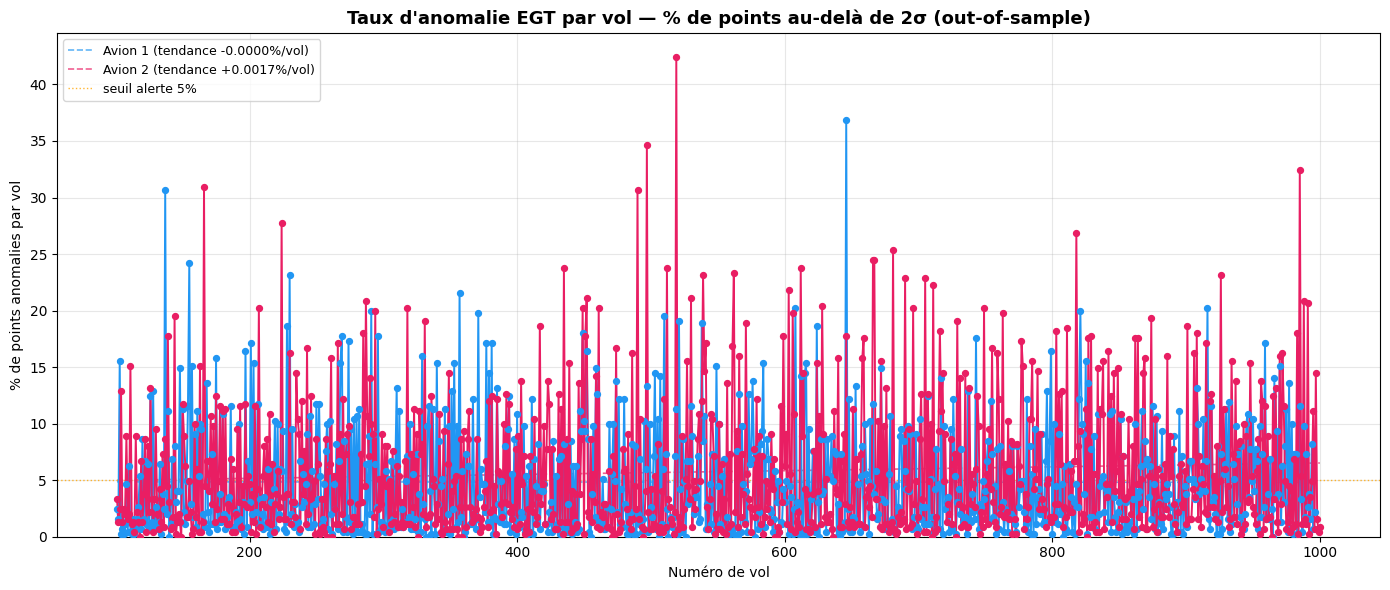

Graphique sauvegardé : visu03_taux_anomalie.png


In [9]:
# ================================================================
# Taux d'anomalie EGT par vol (% points > 2σ)
# ================================================================
COLORS = ['#2196F3', '#E91E63']
avions_a_afficher = ['Avion 1', 'Avion 2']

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title("Taux d'anomalie EGT par vol — % de points au-delà de 2σ (out-of-sample)",
             fontsize=13, fontweight='bold')

# Calcul du seuil 2σ global (tous avions confondus, out-of-sample)
# pour que la comparaison inter-avions soit équitable
all_residuals_oos = []
for nom in avions_a_afficher:
    p              = pipelines[nom]
    contexts       = p['contexts']
    residuals_norm = p['residuals_norm']
    lgbm_model     = p['lgbm_model']
    VAR_CTX_F_C    = p['VAR_CTX_F_C']
    VAR_MOT_F_C    = p['VAR_MOT_F_C']
    TARGET_C       = p['TARGET_C']

    mask_oos = contexts['id_vol'] > N_TRAIN_VOLS
    X_oos    = pd.concat([contexts[mask_oos][VAR_CTX_F_C],
                          residuals_norm[mask_oos][VAR_MOT_F_C]], axis=1)
    Y_oos    = contexts[mask_oos][TARGET_C]
    egt_pred = pd.Series(lgbm_model.predict(X_oos), index=Y_oos.index)
    all_residuals_oos.append((Y_oos - egt_pred).values)

sigma_global = np.concatenate(all_residuals_oos).std()
seuil = 2 * sigma_global
print(f"Seuil global 2σ : {seuil:.2f}°C")

# Tracé par avion
for nom, color in zip(avions_a_afficher, COLORS):
    p              = pipelines[nom]
    contexts       = p['contexts']
    residuals_norm = p['residuals_norm']
    lgbm_model     = p['lgbm_model']
    VAR_CTX_F_C    = p['VAR_CTX_F_C']
    VAR_MOT_F_C    = p['VAR_MOT_F_C']
    TARGET_C       = p['TARGET_C']

    mask_oos   = contexts['id_vol'] > N_TRAIN_VOLS
    ctx_oos    = contexts[mask_oos]
    res_oos    = residuals_norm[mask_oos]
    id_vol_oos = ctx_oos['id_vol']

    X_oos    = pd.concat([ctx_oos[VAR_CTX_F_C], res_oos[VAR_MOT_F_C]], axis=1)
    Y_oos    = ctx_oos[TARGET_C]
    egt_pred = pd.Series(lgbm_model.predict(X_oos), index=Y_oos.index)
    residual = (Y_oos - egt_pred).abs()

    # Taux d'anomalie par vol
    df_anomalie = pd.DataFrame({
        'id_vol'  : id_vol_oos,
        'anomalie': residual > seuil,
    }).groupby('id_vol')['anomalie'].mean().reset_index()
    df_anomalie['anomalie'] *= 100  # en %

    ids  = df_anomalie['id_vol'].values
    vals = df_anomalie['anomalie'].values

    ax.plot(ids, vals, color=color, linewidth=1.4, zorder=3)
    ax.scatter(ids, vals, color=color, s=18, zorder=4)

    # Tendance linéaire
    z = np.polyfit(ids, vals, 1)
    ax.plot(ids, np.poly1d(z)(ids),
            color=color, linewidth=1.2, linestyle='--', alpha=0.7,
            label=f'{nom} (tendance {z[0]:+.4f}%/vol)')

# Ligne de référence à 5% (seuil d'alerte arbitraire mais courant)
ax.axhline(5, color='orange', linewidth=1.0, linestyle=':', alpha=0.8, label='seuil alerte 5%')

ax.set_xlabel("Numéro de vol", fontsize=10)
ax.set_ylabel("% de points anomalies par vol", fontsize=10)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig("visu03_taux_anomalie.png", dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : visu03_taux_anomalie.png")